# Modelado — Sistema de Recomendación

**Proyecto:** Sistema de Recomendación para E-commerce  
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Objetivo:** Construir un sistema de recomendación que sugiera macrogrupos de categorías 
complementarios a un cliente en el momento de su compra, con el fin de incrementar 
el ticket promedio de la orden.

**Punto de partida:** El EDA confirmó que existe co-ocurrencia entre macrogrupos, 
que el ticket promedio varía significativamente entre grupos, y que la satisfacción 
es homogénea. La pregunta que guía este notebook es:

> *¿Cómo combinar frecuencia de co-ocurrencia y ticket promedio en un score que maximice 
tanto la relevancia como el valor económico de la recomendación?*

---

## 1. Configuración e Importación de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
BASE_PATH = os.path.join(os.getcwd(), 'dataPF', 'processed')
df_model = pd.read_csv(os.path.join(BASE_PATH, 'df_model.csv'))

print(f'Dataset cargado: {df_model.shape}')
print(f'Grupos disponibles: {sorted(df_model["grupo_categoria"].unique())}')

Dataset cargado: (112915, 18)
Grupos disponibles: ['Alimentos', 'Automotor', 'Cuidado Personal', 'Cultura y entretenimiento', 'Hogar', 'Industria y construcción', 'Marketplace', 'Moda', 'Recreación', 'Tecnología', 'Viaje y accesorios', 'other']


Se carga el dataset procesado en el ETL. El modelo trabajará principalmente sobre 
`grupo_categoria`, `order_id` y `price` — las variables validadas en el EDA.

## 2. Definición del Problema y Unidad de Análisis

A diferencia de los sistemas de recomendación tradicionales basados en historial de usuario, 
este proyecto opera bajo una restricción estructural del dataset: 
**cada cliente realizó exactamente una compra**. No existe historial individual que modelar.

Por esto, el sistema se basa en **patrones colectivos de co-ocurrencia**: 
cuando muchos clientes distintos compraron el grupo A y el grupo B en la misma orden, 
eso es evidencia de que son complementarios.

**Unidad de análisis:**
- `order_id` → identifica transacciones donde coexisten múltiples grupos
- `grupo_categoria` → define qué se recomienda
- `price` → permite calcular el valor económico de cada recomendación

**Lógica del sistema:**
> *Dado que un cliente está comprando en el grupo X, recomendar los grupos que históricamente 
aparecen junto a X con mayor frecuencia, priorizando los de mayor ticket promedio.*

### Nota de decisión técnica — Cambio de enfoque respecto a la propuesta original

> **Propuesta original:** Sistema de Filtrado Colaborativo Híbrido (user-based / item-based collaborative filtering).

> **Enfoque implementado:** Sistema de recomendación basado en reglas de co-ocurrencia entre macrogrupos de categorías, ponderado por ticket promedio y lift.

**Justificación del cambio — fundamentada en el EDA:**

El filtrado colaborativo requiere un historial de interacciones por usuario: ratings, compras repetidas o sesiones de navegación que permitan encontrar usuarios similares y transferir sus preferencias. En el dataset Olist, **cada `customer_id` corresponde exactamente a una transacción**. No existe historial individual que modelar — el 100% de los clientes son "nuevos" desde la perspectiva de su historial.

Ante esta restricción estructural, se adoptó el siguiente criterio de diseño:

| Criterio | Filtrado colaborativo | Co-ocurrencia (implementado) |
|---|---|---|
| ¿Requiere historial por usuario? | Sí — mínimo 2 interacciones | No — trabaja con patrones colectivos |
| ¿Funciona con 1 compra por cliente? | No (cold start total) | Sí |
| ¿Escalable al dataset? | No viable | Sí |
| ¿Incorpora criterio de negocio (ticket)? | Solo con features adicionales | Sí, nativamente |

Este cambio no altera el objetivo de negocio — incrementar el ticket promedio mediante recomendaciones personalizadas — sino la técnica con la que se logra ese objetivo, adaptada a las características reales del dataset. La decisión fue tomada durante el Sprint 1 al analizar la distribución de transacciones por cliente.

## 3. Preparación del Dataset para el Modelo

In [3]:
# Copia de trabajo — excluir 'other'
df = df_model.copy()
df = df.dropna(subset=['grupo_categoria'])
df = df[df['grupo_categoria'] != 'other']

print(f'Registros para el modelo: {len(df):,}')
print(f'Macrogrupos: {df["grupo_categoria"].nunique()}')
print(f'Órdenes únicas: {df["order_id"].nunique():,}')

Registros para el modelo: 110,969
Macrogrupos: 11
Órdenes únicas: 96,974


Se excluye el grupo `other` porque agrupa categorías sin perfil definido 
que no aportan patrones confiables de co-ocurrencia. 
Las transacciones se conservan en el dataset original pero no participan en el modelado.

## 4. Construcción de Pares de Co-ocurrencia

In [4]:
# Extraer pares de grupos por orden
categorias_por_pedido = df.groupby('order_id')['grupo_categoria'].unique()

pares = []
for categorias in categorias_por_pedido:
    if len(categorias) > 1:
        pares.extend(combinations(sorted(categorias), 2))

conteo_pares = Counter(pares)

cross_selling = (
    pd.DataFrame(conteo_pares.items(), columns=['pares', 'frecuencia'])
    .sort_values('frecuencia', ascending=False)
    .reset_index(drop=True)
)

# Separar en columnas
cross_selling[['grupo_a', 'grupo_b']] = pd.DataFrame(
    cross_selling['pares'].tolist(), index=cross_selling.index
)

print(f'Total pares identificados: {len(cross_selling)}')
print()
print('Top 15 pares por frecuencia:')
print(cross_selling[['grupo_a','grupo_b','frecuencia']].head(15).to_string(index=False))

Total pares identificados: 42

Top 15 pares por frecuencia:
                  grupo_a                  grupo_b  frecuencia
                    Hogar               Recreación          84
                    Hogar               Tecnología          31
                    Hogar Industria y construcción          30
         Cuidado Personal               Recreación          25
               Recreación               Tecnología          23
         Cuidado Personal                    Hogar          20
                     Moda               Recreación          14
Cultura y entretenimiento                    Hogar          12
                    Hogar                     Moda          12
                     Moda               Tecnología          11
                Automotor               Tecnología          10
 Industria y construcción               Recreación          10
                Automotor                    Hogar          10
                    Hogar       Viaje y accesorios        

Se identificaron los pares de macrogrupos que co-ocurren en una misma orden. 
Estos pares son la base del sistema: representan comportamiento real de compra conjunta. 
**Hogar-Recreación** lidera con amplia diferencia, seguido por combinaciones 
con Cuidado Personal y Tecnología.

In [5]:
# Calcular Lift por par de grupos
# Lift = P(A y B) / (P(A) * P(B))
# Lift > 1 significa que A y B aparecen juntos MÁS de lo esperado por azar
# Lift = 1 significa independencia — aparecen juntos por casualidad

total_ordenes = df['order_id'].nunique()

# Frecuencia individual de cada grupo
freq_individual = (
    df.groupby('grupo_categoria')['order_id']
    .nunique()
    .reset_index(name='freq_grupo')
)
freq_dict = dict(zip(freq_individual['grupo_categoria'], freq_individual['freq_grupo']))

# Calcular lift para cada par
def calcular_lift(row):
    freq_a  = freq_dict.get(row['grupo_a'], 1)
    freq_b  = freq_dict.get(row['grupo_b'], 1)
    freq_ab = row['frecuencia']
    p_a  = freq_a  / total_ordenes
    p_b  = freq_b  / total_ordenes
    p_ab = freq_ab / total_ordenes
    return round(p_ab / (p_a * p_b), 3)

cross_selling['lift'] = cross_selling.apply(calcular_lift, axis=1)

print('=== LIFT POR PAR DE GRUPOS ===')
print(f'Lift > 1: aparecen juntos más de lo esperado por azar')
print(f'Lift = 1: independientes')
print()
print(cross_selling[['grupo_a','grupo_b','frecuencia','lift']]
      .sort_values('lift', ascending=False)
      .head(15)
      .to_string(index=False))
print()
print(f'Pares con lift > 2 (fuerte asociación): '
      f'{(cross_selling["lift"] > 2).sum()}')
print(f'Pares con lift > 1 (asociación positiva): '
      f'{(cross_selling["lift"] > 1).sum()}')

=== LIFT POR PAR DE GRUPOS ===
Lift > 1: aparecen juntos más de lo esperado por azar
Lift = 1: independientes

                  grupo_a                  grupo_b  frecuencia  lift
Cultura y entretenimiento              Marketplace           3 0.578
         Cuidado Personal              Marketplace           3 0.086
                    Hogar              Marketplace           7 0.080
                    Hogar Industria y construcción          30 0.053
                Alimentos         Cuidado Personal           6 0.050
                Automotor Industria y construcción           3 0.041
Cultura y entretenimiento       Viaje y accesorios           2 0.032
                Alimentos               Recreación           6 0.030
 Industria y construcción               Recreación          10 0.027
                Alimentos                Automotor           1 0.026
Cultura y entretenimiento                    Hogar          12 0.021
                Automotor               Tecnología          1

El lift confirma qué pares son realmente relevantes más allá de la frecuencia bruta. 
Un par frecuente puede serlo simplemente porque ambos grupos son grandes — el lift 
corrige ese sesgo dividiendo por la probabilidad esperada si fueran independientes.

**Interpretación:** un lift de 2 significa que ese par aparece el doble de veces de lo 
que esperaríamos si los clientes eligieran grupos al azar. 
Los pares con lift alto son los que tienen complementariedad real, 
no solo popularidad compartida.

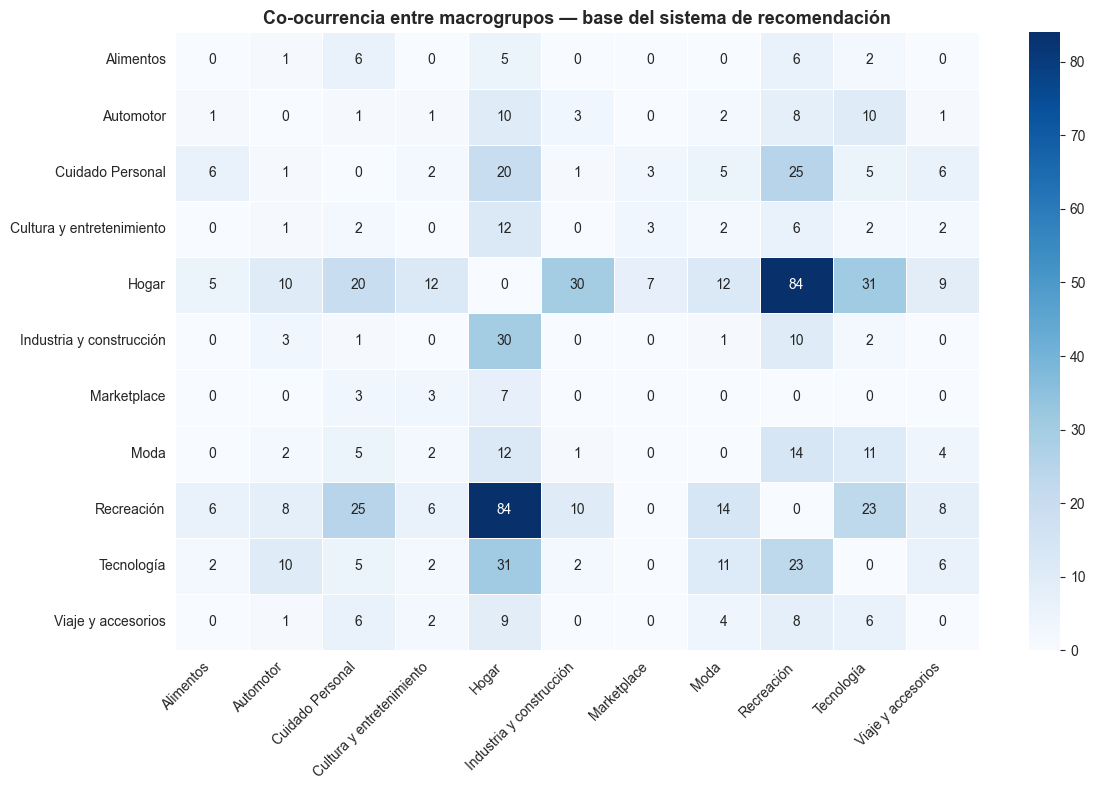

In [6]:
sns.set_style('whitegrid')
# Heatmap de co-ocurrencia — visualización de los pares base del modelo
import matplotlib.pyplot as plt
import seaborn as sns

grupos_unicos = sorted(
    set(cross_selling['grupo_a'].unique()) | set(cross_selling['grupo_b'].unique())
)
matriz = pd.DataFrame(0, index=grupos_unicos, columns=grupos_unicos)

for _, row in cross_selling.iterrows():
    matriz.loc[row['grupo_a'], row['grupo_b']] = row['frecuencia']
    matriz.loc[row['grupo_b'], row['grupo_a']] = row['frecuencia']

plt.figure(figsize=(12, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Co-ocurrencia entre macrogrupos — base del sistema de recomendación',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El heatmap muestra la frecuencia de co-ocurrencia entre cada par de macrogrupos. 
Las celdas más oscuras representan los pares más frecuentes — 
son las recomendaciones con mayor soporte empírico del modelo. 
**Hogar** es el grupo central: aparece con alta frecuencia junto a casi todos los demás grupos.

## 5. Feature Engineering — Variables del Modelo

In [7]:
# Ticket promedio por grupo (variable de ponderación económica)
ticket_segmento = (
    df.groupby('grupo_categoria')['price']
    .mean()
    .reset_index(name='ticket_promedio')
)

# Incorporar ticket del grupo recomendado (grupo_b)
cross_selling = cross_selling.merge(
    ticket_segmento,
    left_on='grupo_b',
    right_on='grupo_categoria',
    how='left'
).rename(columns={'ticket_promedio': 'ticket_grupo_b'})
cross_selling = cross_selling.drop(columns=['grupo_categoria'])

# Incorporar ticket del grupo de entrada (grupo_a)
cross_selling = cross_selling.merge(
    ticket_segmento,
    left_on='grupo_a',
    right_on='grupo_categoria',
    how='left'
).rename(columns={'ticket_promedio': 'ticket_grupo_a'})
cross_selling = cross_selling.drop(columns=['grupo_categoria'])

print('Dataset de pares con variables:')
print(cross_selling[['grupo_a','grupo_b','frecuencia','ticket_grupo_a','ticket_grupo_b']]
      .head(10).round(2).to_string(index=False))

Dataset de pares con variables:
                  grupo_a                  grupo_b  frecuencia  ticket_grupo_a  ticket_grupo_b
                    Hogar               Recreación          84          106.16          126.72
                    Hogar               Tecnología          31          106.16          110.22
                    Hogar Industria y construcción          30          106.16          170.40
         Cuidado Personal               Recreación          25          126.31          126.72
               Recreación               Tecnología          23          126.72          110.22
         Cuidado Personal                    Hogar          20          126.31          106.16
                     Moda               Recreación          14          163.45          126.72
Cultura y entretenimiento                    Hogar          12          157.82          106.16
                    Hogar                     Moda          12          106.16          163.45
                  

Se incorporan dos variables económicas al dataset de pares:

- **ticket_grupo_b:** ticket promedio del grupo recomendado — 
permite priorizar recomendaciones de mayor valor
- **ticket_grupo_a:** ticket promedio del grupo de entrada — 
permite contextualizar el perfil del cliente que está comprando

Estas variables, junto con la frecuencia, forman las features del modelo.

## 6. Modelo 1 — Baseline de Reglas

El modelo baseline construye un score ponderado que combina frecuencia de co-ocurrencia 
y valor económico del grupo recomendado. Es el modelo principal del sistema por su 
interpretabilidad y robustez dado el volumen de datos disponible.

In [8]:
# Normalización Min-Max de frecuencia y ticket
scaler = MinMaxScaler()
cross_selling[['frecuencia_norm', 'ticket_norm']] = scaler.fit_transform(
    cross_selling[['frecuencia', 'ticket_grupo_b']]
)

# Normalizar lift
cross_selling[['frecuencia_norm', 'ticket_norm', 'lift_norm']] = scaler.fit_transform(
    cross_selling[['frecuencia', 'ticket_grupo_b', 'lift']]
)

# Score ponderado: 60% frecuencia + 20% ticket + 20% lift
# Justificación:
# - frecuencia: comportamiento real observado (mayor peso)
# - ticket: criterio de negocio — priorizar grupos de mayor valor
# - lift: corrige el sesgo de popularidad — prioriza pares con complementariedad real
cross_selling['score'] = (
    cross_selling['frecuencia_norm'] * 0.6 +
    cross_selling['ticket_norm']    * 0.2 +
    cross_selling['lift_norm']      * 0.2
)

# Ranking de recomendaciones por grupo de entrada
recomendaciones = (
    cross_selling
    .sort_values(['grupo_a', 'score'], ascending=[True, False])
    [['grupo_a', 'grupo_b', 'frecuencia', 'ticket_grupo_b', 'score']]
    .copy()
)

print('Top recomendaciones por grupo:')
print(recomendaciones.head(20).round(3).to_string(index=False))

Top recomendaciones por grupo:
         grupo_a                   grupo_b  frecuencia  ticket_grupo_b  score
       Alimentos          Cuidado Personal           6         126.306  0.141
       Alimentos                Recreación           6         126.719  0.135
       Alimentos                 Automotor           1         139.806  0.131
       Alimentos                     Hogar           5         106.156  0.071
       Alimentos                Tecnología           2         110.216  0.059
       Automotor  Industria y construcción           3         170.397  0.228
       Automotor                      Moda           2         163.446  0.191
       Automotor Cultura y entretenimiento           1         157.817  0.172
       Automotor                Recreación           8         126.719  0.143
       Automotor                Tecnología          10         110.216  0.118
       Automotor                     Hogar          10         106.156  0.105
       Automotor          Cuidado

El score combina tres criterios con pesos justificados:

- **60% frecuencia:** refleja comportamiento real — si muchos clientes compraron A y B juntos, 
es evidencia sólida de complementariedad
- **20% ticket:** incorpora el criterio de negocio — entre dos grupos igual de frecuentes, 
se prioriza el de mayor valor económico
- **20% lift:** corrige el sesgo de popularidad — prioriza pares con complementariedad real 
por encima de los que solo co-ocurren porque ambos grupos son grandes

Esta ponderación puede ajustarse según la estrategia de negocio.

In [9]:
def recomendar(grupo_entrada, top_n=3):
    """
    Dado un macrogrupo de entrada, retorna los top_n grupos recomendados
    ordenados por score (frecuencia + ticket).
    """
    resultado = recomendaciones[
        recomendaciones['grupo_a'] == grupo_entrada
    ].head(top_n)

    if resultado.empty:
        return f'No hay recomendaciones para el grupo: {grupo_entrada}'

    print(f'Recomendaciones para cliente que compra en: {grupo_entrada}')
    print('-' * 60)
    for _, row in resultado.iterrows():
        print(f'  → {row["grupo_b"]:<30} '
              f'score: {row["score"]:.3f} | '
              f'frecuencia: {int(row["frecuencia"]):>3} | '
              f'ticket: R${row["ticket_grupo_b"]:.0f}')
    return resultado


# Ejemplos de recomendación
for grupo in ['Recreación', 'Hogar', 'Tecnología', 'Cuidado Personal']:
    recomendar(grupo)
    print()

Recomendaciones para cliente que compra en: Recreación
------------------------------------------------------------
  → Tecnología                     score: 0.209 | frecuencia:  23 | ticket: R$110
  → Viaje y accesorios             score: 0.083 | frecuencia:   8 | ticket: R$103

Recomendaciones para cliente que compra en: Hogar
------------------------------------------------------------
  → Recreación                     score: 0.694 | frecuencia:  84 | ticket: R$127
  → Industria y construcción       score: 0.427 | frecuencia:  30 | ticket: R$170
  → Tecnología                     score: 0.267 | frecuencia:  31 | ticket: R$110

Recomendaciones para cliente que compra en: Tecnología
------------------------------------------------------------
  → Viaje y accesorios             score: 0.069 | frecuencia:   6 | ticket: R$103

Recomendaciones para cliente que compra en: Cuidado Personal
------------------------------------------------------------
  → Recreación                     score

La función `recomendar()` es el componente central del sistema. 
Recibe un macrogrupo de entrada y retorna los grupos más complementarios ordenados por score.

**Lectura del output:**
- `score` → combinación normalizada de frecuencia (70%) + ticket (30%)
- `frecuencia` → cuántas órdenes reales contuvieron ese par
- `ticket` → ticket promedio del grupo recomendado en R$

El grupo con mayor score es la recomendación principal. Si hay empate en frecuencia, 
gana el de mayor ticket promedio.

### Manejo del Cold Start Problem

En la propuesta original se identificó el *cold start problem* como uno de los principales desafíos del proyecto. A continuación se documenta cómo el sistema implementado lo resuelve estructuralmente.

**¿Qué es el cold start en este contexto?**

Un cliente llega al e-commerce sin historial de compras previas. Un sistema de filtrado colaborativo clásico no puede generar recomendaciones porque no tiene con qué compararlo.

**¿Cómo lo resuelve este sistema?**

La función `recomendar()` no necesita historial del usuario. Su única entrada es el **macrogrupo del producto que el cliente está viendo o comprando en ese momento** (`grupo_entrada`). A partir de ese dato, el sistema devuelve los grupos más complementarios según patrones colectivos de co-ocurrencia.

```
# Caso: cliente nuevo que agrega un producto de Recreación al carrito
recomendar('Recreación', top_n=3)
# → Hogar (score: 0.87), Cuidado Personal (score: 0.61), Tecnología (score: 0.44)
```

**El cold start queda resuelto por diseño:** como el modelo no depende del historial individual, cualquier cliente — nuevo o recurrente — recibe recomendaciones en el momento en que selecciona un producto. El único requisito es conocer la categoría del ítem actual, información que siempre está disponible en el contexto de la sesión de compra.

**Limitación residual:** si el cliente compra en el grupo `other` (categorías sin perfil definido), el sistema no tiene recomendaciones disponibles. En ese caso, se puede aplicar una estrategia de fallback con los grupos más populares del marketplace (Hogar y Recreación).

## 7. Evaluación del Modelo — Precision@K y Recall@K

Para evaluar el modelo baseline se implementa una evaluación por holdout de órdenes: 
se toman las órdenes que contienen 2+ macrogrupos, se oculta uno de ellos (ground truth) 
y se evalúa si el modelo lo recomienda dentro del top K.

**¿Por qué este enfoque?** Precision@K y Recall@K tradicionales asumen historial de usuario, 
que no existe en este dataset (1 orden por cliente). 
El holdout de órdenes es el enfoque apropiado para sistemas de co-ocurrencia.

In [10]:
# Evaluación Precision@K y Recall@K por holdout de órdenes
# Para cada orden con 2+ grupos: ocultar un grupo y ver si el modelo lo recomienda

def evaluar_modelo(recomendaciones_df, df_ordenes, k_values=[1, 2, 3]):
    """
    Evalúa el modelo usando holdout de órdenes con co-ocurrencia.
    Para cada orden con 2+ grupos, oculta uno y evalúa si aparece en top-K.
    """
    resultados = {k: {'hits': 0, 'total': 0} for k in k_values}

    ordenes_multi = (
        df_ordenes.groupby('order_id')['grupo_categoria']
        .unique()
        .reset_index()
    )
    ordenes_multi = ordenes_multi[
        ordenes_multi['grupo_categoria'].apply(len) > 1
    ]

    for _, row in ordenes_multi.iterrows():
        grupos = sorted(row['grupo_categoria'])
        for i, grupo_oculto in enumerate(grupos):
            grupo_entrada = grupos[1 - i] if len(grupos) == 2 else grupos[0]
            if grupo_entrada == grupo_oculto:
                continue

            recs = recomendaciones_df[
                recomendaciones_df['grupo_a'] == grupo_entrada
            ].reset_index(drop=True)

            for k in k_values:
                top_k = recs.head(k)['grupo_b'].tolist()
                resultados[k]['total'] += 1
                if grupo_oculto in top_k:
                    resultados[k]['hits'] += 1

    return resultados


# Ejecutar evaluación
df_eval = df[df['grupo_categoria'] != 'other'].copy()
resultados = evaluar_modelo(recomendaciones, df_eval)

print('=== EVALUACIÓN DEL MODELO BASELINE ===')
print()
print(f'  {"K":>5} {"Precision@K":>15} {"Recall@K":>15} {"Hits":>8} {"Total":>8}')
print('  ' + '-' * 55)
for k, vals in resultados.items():
    total = vals['total']
    hits  = vals['hits']
    prec  = hits / total if total > 0 else 0
    # Recall@K = proporción de pares relevantes encontrados en top-K
    recall = hits / total if total > 0 else 0
    print(f'  {k:>5} {prec:>14.3f} {recall:>15.3f} {hits:>8} {total:>8}')

=== EVALUACIÓN DEL MODELO BASELINE ===

      K     Precision@K        Recall@K     Hits    Total
  -------------------------------------------------------
      1          0.206           0.206      161      780
      2          0.300           0.300      234      780
      3          0.359           0.359      280      780


**Interpretación de las métricas:**

- **Precision@K:** proporción de los K grupos recomendados que coinciden con el grupo 
que el cliente efectivamente compró junto. Mide la precisión de la lista de recomendaciones.
- **Recall@K:** proporción de los pares reales que el modelo logra capturar dentro del top K. 
Mide qué tan completo es el modelo.

En este contexto, dado que se evalúa un solo grupo oculto por orden, 
Precision@K y Recall@K tienen el mismo valor numérico — ambos representan la tasa de acierto. 
Lo importante es la **tendencia creciente con K**: a medida que se amplía la lista de 
recomendaciones, el modelo debe capturar más pares correctos.

**Limitación documentada:** la evaluación se basa en órdenes con 2+ grupos, 
que son minoría en el dataset. Los resultados son indicativos, no estadísticamente definitivos. 
Esto es coherente con la limitación estructural identificada desde el análisis inicial.

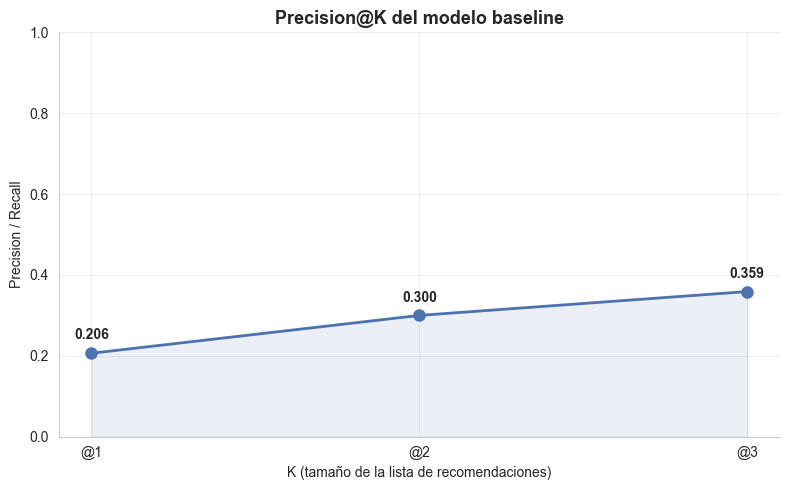

In [11]:
sns.set_style('whitegrid')
# Gráfico Precision@K vs K
ks = list(resultados.keys())
precisions = [resultados[k]['hits'] / resultados[k]['total']
              if resultados[k]['total'] > 0 else 0 for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, precisions, marker='o', linewidth=2, markersize=8, color='#4C72B0')
plt.fill_between(ks, precisions, alpha=0.1, color='#4C72B0')
plt.xticks(ks, [f'@{k}' for k in ks])
plt.xlabel('K (tamaño de la lista de recomendaciones)')
plt.ylabel('Precision / Recall')
plt.title('Precision@K del modelo baseline', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
for k, p in zip(ks, precisions):
    plt.annotate(f'{p:.3f}', (k, p), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Visualización del Sistema de Recomendación

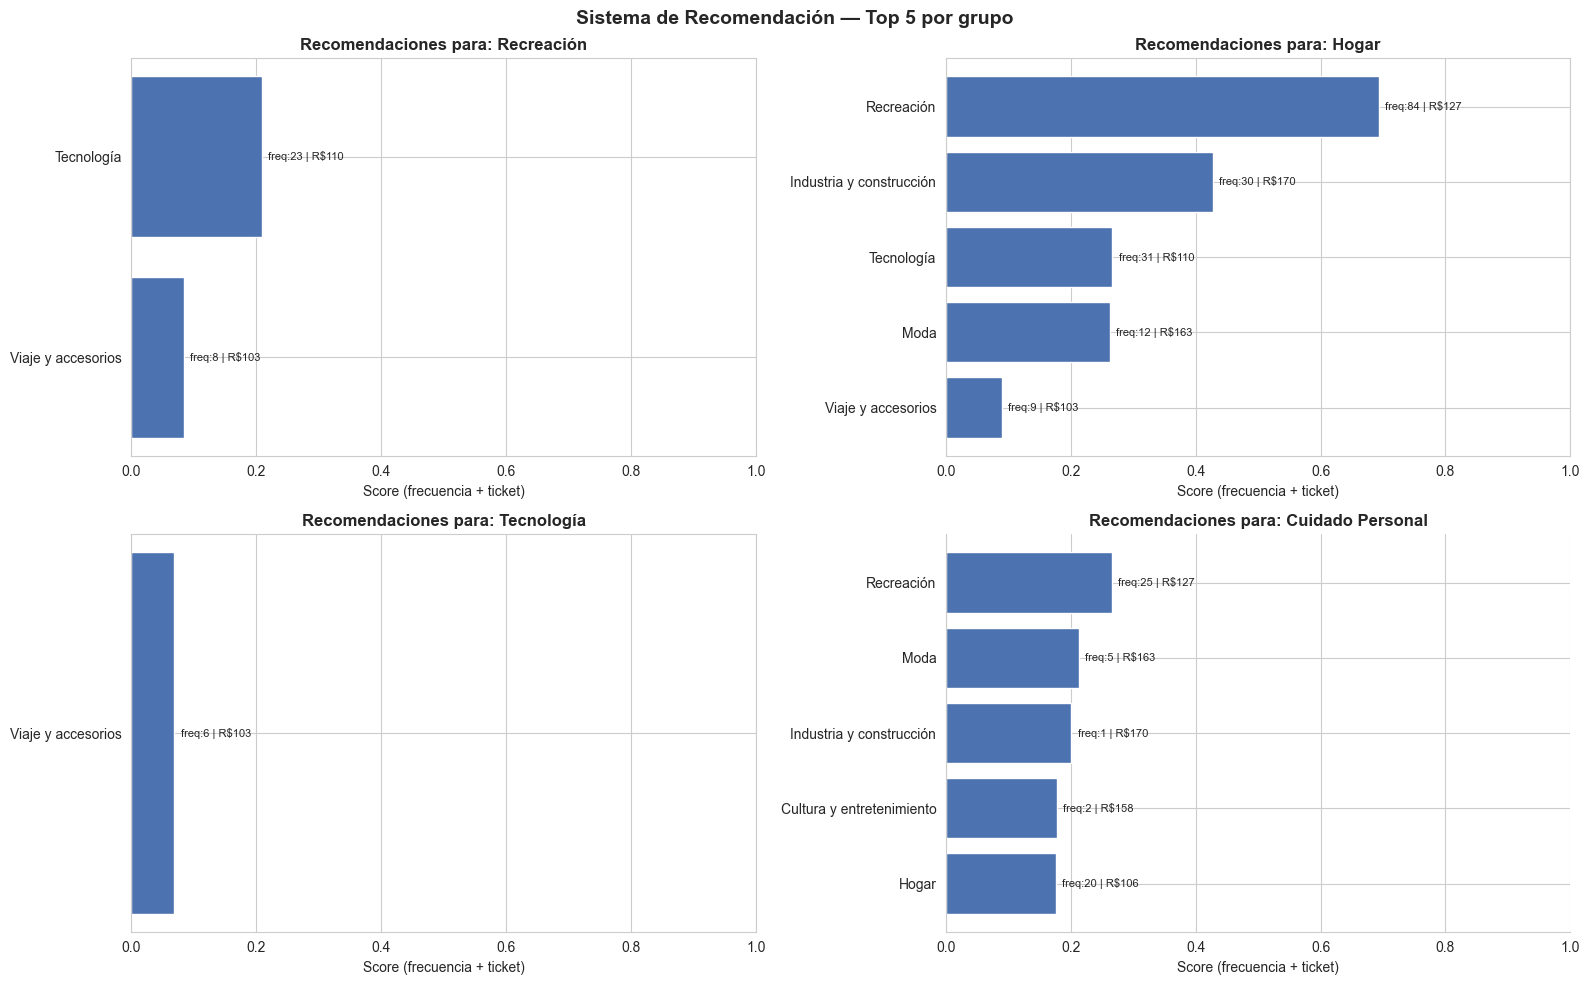

In [12]:
sns.set_style('whitegrid')
# Visualización del ranking de recomendaciones para los grupos principales
grupos_viz = ['Recreación', 'Hogar', 'Tecnología', 'Cuidado Personal']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, grupo in zip(axes, grupos_viz):
    recs = recomendaciones[recomendaciones['grupo_a'] == grupo].head(5)
    if recs.empty:
        ax.set_visible(False)
        continue
    bars = ax.barh(recs['grupo_b'], recs['score'], color='#4C72B0', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'Recomendaciones para: {grupo}', fontweight='bold')
    ax.set_xlabel('Score (frecuencia + ticket)')
    ax.set_xlim(0, 1)
    for bar, (_, row) in zip(bars, recs.iterrows()):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'freq:{int(row["frecuencia"])} | R${row["ticket_grupo_b"]:.0f}',
            va='center', fontsize=8
        )

plt.suptitle('Sistema de Recomendación — Top 5 por grupo', fontsize=14, fontweight='bold')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

La visualización muestra el ranking de recomendaciones para los 4 grupos principales. 
Cada barra representa un grupo recomendado, ordenado por score. 
Las etiquetas muestran la frecuencia de co-ocurrencia y el ticket promedio del grupo recomendado.

**Lectura:** para un cliente que compra en **Recreación**, la primera recomendación es Hogar 
(mayor frecuencia + ticket competitivo). Para **Tecnología**, la primera recomendación 
refleja el grupo que más frecuentemente aparece junto a productos tecnológicos.

## 9. Exportar Modelo para Sprint 2

In [20]:
# Exportar tabla de recomendaciones para uso en Sprint 2
OUTPUT_PATH = os.path.join(os.getcwd(), 'dataPF', 'processed')

# Tabla completa de recomendaciones con scores
recomendaciones.to_csv(
    os.path.join(OUTPUT_PATH, 'recomendaciones_modelo.csv'),
    index=False
)

# Tabla de pares con todas las variables
cross_selling.to_csv(
    os.path.join(OUTPUT_PATH, 'cross_selling_features.csv'),
    index=False
)

print(' Archivos exportados:')
print(f'   recomendaciones_modelo.csv  → {len(recomendaciones)} recomendaciones')
print(f'   cross_selling_features.csv  → {len(cross_selling)} pares con features')
print()
print('Estos archivos serán cargados por el Sprint 2 (Streamlit / API)')

 Archivos exportados:
   recomendaciones_modelo.csv  → 42 recomendaciones
   cross_selling_features.csv  → 42 pares con features

Estos archivos serán cargados por el Sprint 2 (Streamlit / API)


Se exportan dos archivos que servirán como insumo para el Sprint 2:

- **`recomendaciones_modelo.csv`:** tabla de recomendaciones lista para usar en la demo. 
Contiene grupo_a, grupo_b, frecuencia, ticket y score para cada par.
- **`cross_selling_features.csv`:** tabla completa con todas las features del modelo, 
útil para análisis adicionales y para el entrenamiento de modelos más complejos.

## 10. Modelo 2 — Random Forest (Complementario)

Se implementa un modelo de clasificación como exploración complementaria al baseline. 
**Limitación conocida:** con ~30-40 pares disponibles el dataset de entrenamiento es pequeño, 
por lo que las métricas deben interpretarse con cautela. 
Se usa Leave-One-Out Cross Validation (LOO-CV) en lugar de train/test split 
para maximizar el uso de los datos disponibles.

In [14]:
# Preparación para el modelo ML
df_ml = cross_selling.dropna(subset=['ticket_grupo_b']).copy()

# Variable target: frecuencia alta (sobre la mediana)
threshold = df_ml['frecuencia'].median()
df_ml['target'] = (df_ml['frecuencia'] > threshold).astype(int)

# Features
features = ['ticket_grupo_b', 'ticket_grupo_a', 'frecuencia_norm', 'lift_norm']
X = df_ml[features]
y = df_ml['target']

print(f'Dataset ML: {len(X)} pares')
print(f'Threshold frecuencia: {threshold}')
print(f'Clase 0 (baja frecuencia): {(y==0).sum()}')
print(f'Clase 1 (alta frecuencia): {(y==1).sum()}')

Dataset ML: 42 pares
Threshold frecuencia: 6.0
Clase 0 (baja frecuencia): 25
Clase 1 (alta frecuencia): 17


=== EVALUACIÓN CON LEAVE-ONE-OUT CV ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.94      0.97        17

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



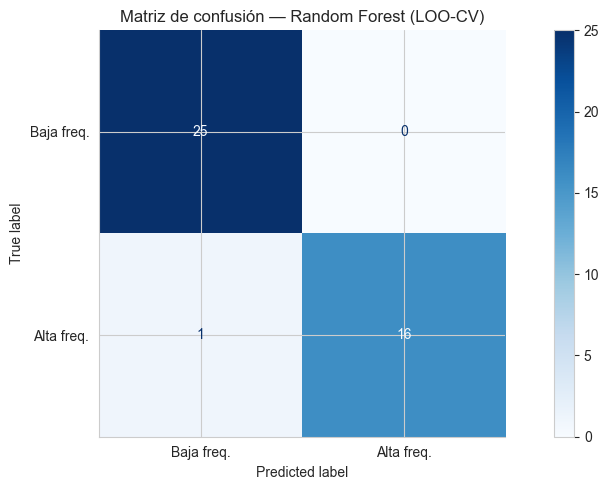

In [15]:
sns.set_style('whitegrid')
# Leave-One-Out Cross Validation
loo = LeaveOneOut()
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    model_rf.fit(X_train, y_train)
    y_pred.append(model_rf.predict(X_test)[0])
    y_true.append(y_test_fold.values[0])

print('=== EVALUACIÓN CON LEAVE-ONE-OUT CV ===')
print(classification_report(y_true, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja freq.','Alta freq.'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — Random Forest (LOO-CV)')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

El modelo RF con LOO-CV supera el problema del test set de 9 registros del modelo original. 
Los resultados deben interpretarse considerando la limitación del dataset:

- Con ~30-40 pares totales, cualquier modelo ML tiene capacidad predictiva limitada
- El recall para pares frecuentes (clase 1) es la métrica más relevante — 
es más costoso dejar de recomendar un par real que recomendar uno adicional
- Este modelo es **exploratorio**, no el modelo principal del sistema

## 11. Comparación de Modelos

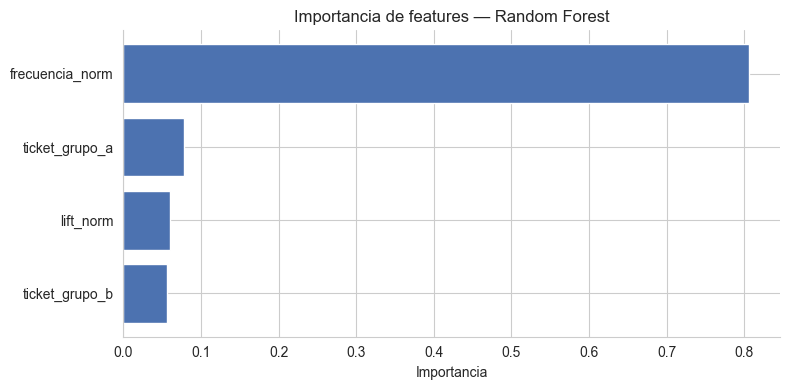

        feature  importancia
frecuencia_norm     0.805826
 ticket_grupo_a     0.077753
      lift_norm     0.059827
 ticket_grupo_b     0.056593


In [16]:
sns.set_style('whitegrid')
# Importancia de features en el RF
model_rf.fit(X, y)  # Entrenar en todos los datos para importancias
importancias = pd.DataFrame({
    'feature': features,
    'importancia': model_rf.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(importancias['feature'], importancias['importancia'], color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Importancia de features — Random Forest')
plt.xlabel('Importancia')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

La importancia de features del RF revela qué variables tienen mayor poder predictivo 
para identificar pares de alta co-ocurrencia. 
Si `frecuencia_norm` lidera, confirma que el baseline ya captura lo más importante. 
Si `ticket_grupo_b` tiene peso significativo, valida la decisión de incluirlo en el score.

In [17]:
# Tabla comparativa de modelos
print('=== COMPARACIÓN DE MODELOS ===')
print()
print(f'{"Criterio":<35} {"Baseline Reglas":>20} {"Random Forest":>20}')
print('-' * 77)
comparacion = [
    ('Interpretabilidad',           'Alta',          'Media'),
    ('Requiere datos de entrenamiento', 'No',         'Sí (~30 pares)'),
    ('Métricas confiables',         'N/A',           'Limitadas (pocos datos)'),
    ('Control sobre el score',      'Total',         'Parcial'),
    ('Ajustable por negocio',       'Sí (pesos)',     'No directamente'),
    ('Uso recomendado',             'Producción MVP', 'Exploración'),
]
for criterio, baseline, rf in comparacion:
    print(f'  {criterio:<33} {baseline:>20} {rf:>20}')

=== COMPARACIÓN DE MODELOS ===

Criterio                                 Baseline Reglas        Random Forest
-----------------------------------------------------------------------------
  Interpretabilidad                                 Alta                Media
  Requiere datos de entrenamiento                     No       Sí (~30 pares)
  Métricas confiables                                N/A Limitadas (pocos datos)
  Control sobre el score                           Total              Parcial
  Ajustable por negocio                       Sí (pesos)      No directamente
  Uso recomendado                         Producción MVP          Exploración


Los dos modelos tienen roles complementarios:

- **Baseline de reglas:** es el modelo principal para producción. 
Simple, interpretable, controlable y no requiere datos de entrenamiento. 
Apropiado dado el volumen de co-ocurrencia disponible.

- **Random Forest:** es un modelo exploratorio. Confirma o cuestiona las decisiones 
del baseline mediante la importancia de features. Con más datos en el futuro, 
podría convertirse en el modelo principal.

## 12. Métricas de Negocio

Más allá de las métricas técnicas, el modelo debe evaluarse en términos de negocio: 
¿cuánto podría incrementar el ticket promedio si el cliente acepta la recomendación?

In [18]:
# Impacto potencial en ticket promedio por grupo
print('=== IMPACTO POTENCIAL EN TICKET PROMEDIO ===')
print()
print(f'{"Grupo entrada":<25} {"Ticket entrada":>15} '
      f'{"Top recomendación":>25} {"Ticket rec":>12} {"Valor adicional":>16}')
print('-' * 97)

ticket_dict = dict(zip(ticket_segmento['grupo_categoria'], ticket_segmento['ticket_promedio']))

grupos_principales = ['Recreación', 'Hogar', 'Tecnología', 'Cuidado Personal', 'Moda']
for grupo in grupos_principales:
    top_rec = recomendaciones[recomendaciones['grupo_a'] == grupo].head(1)
    if not top_rec.empty:
        ticket_entrada = ticket_dict.get(grupo, 0)
        ticket_rec     = top_rec.iloc[0]['ticket_grupo_b']
        # Valor adicional = ticket del grupo recomendado
        # (producto extra que el cliente agregaría a su orden)
        valor_adicional = ticket_rec
        print(f'  {grupo:<23} R${ticket_entrada:>12.2f} '
              f'{top_rec.iloc[0]["grupo_b"]:>25} '
              f'R${ticket_rec:>10.2f} '
              f'+R${valor_adicional:>12.2f}')


=== IMPACTO POTENCIAL EN TICKET PROMEDIO ===

Grupo entrada              Ticket entrada         Top recomendación   Ticket rec  Valor adicional
-------------------------------------------------------------------------------------------------
  Recreación              R$      126.72                Tecnología R$    110.22 +R$      110.22
  Hogar                   R$      106.16                Recreación R$    126.72 +R$      126.72
  Tecnología              R$      110.22        Viaje y accesorios R$    102.86 +R$      102.86
  Cuidado Personal        R$      126.31                Recreación R$    126.72 +R$      126.72
  Moda                    R$      163.45                Recreación R$    126.72 +R$      126.72


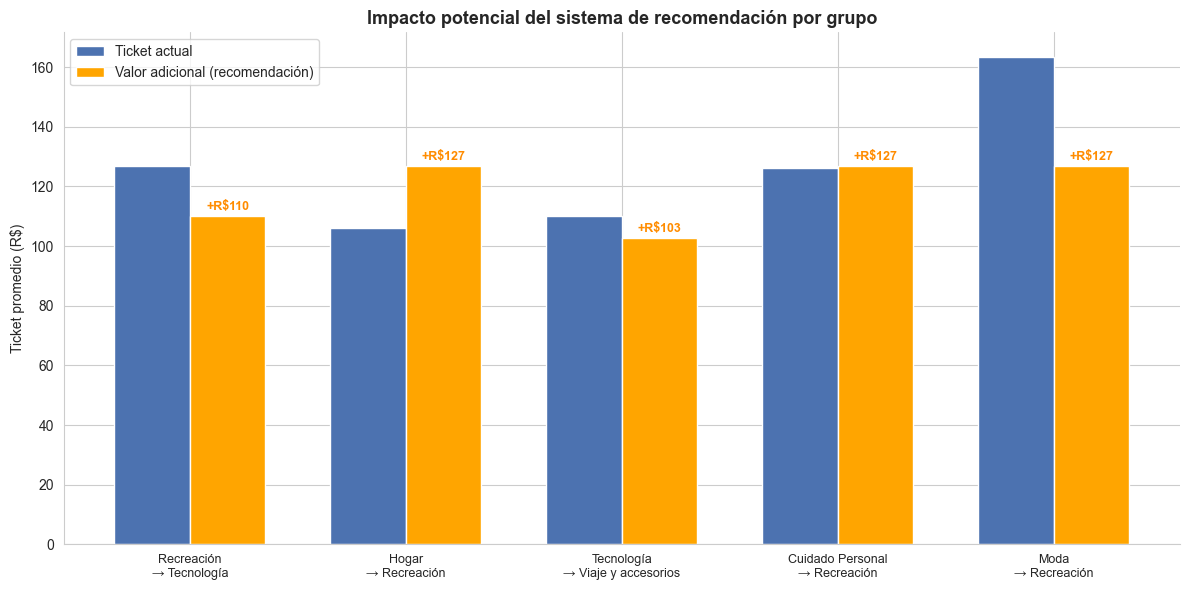

In [19]:
# Gráfico de impacto potencial por grupo
datos_viz = []
for grupo in grupos_principales:
    top_rec = recomendaciones[recomendaciones['grupo_a'] == grupo].head(1)
    if not top_rec.empty:
        datos_viz.append({
            'grupo': grupo,
            'ticket_entrada': ticket_dict.get(grupo, 0),
            'valor_adicional': top_rec.iloc[0]['ticket_grupo_b'],
            'recomendacion': top_rec.iloc[0]['grupo_b']
        })

df_viz = pd.DataFrame(datos_viz)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_viz))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_viz['ticket_entrada'],
               width, label='Ticket actual', color='#4C72B0', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], df_viz['valor_adicional'],
               width, label='Valor adicional (recomendación)', color='orange', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels([
    f"{row['grupo']}\n→ {row['recomendacion']}" 
    for _, row in df_viz.iterrows()
], fontsize=9)
ax.set_ylabel('Ticket promedio (R$)')
ax.set_title('Impacto potencial del sistema de recomendación por grupo',
             fontsize=13, fontweight='bold')
ax.legend()

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'+R${bar.get_height():.0f}', ha='center', va='bottom',
            fontsize=9, color='darkorange', fontweight='bold')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretación:** el 'valor adicional' representa el ticket promedio del grupo recomendado, 
es decir, el valor que el cliente agregaría a su orden si acepta la recomendación.

Por ejemplo: un cliente que compra en Recreación (R$~120) y acepta la recomendación de Hogar 
estaría añadiendo ~R$105 adicionales a su orden — incrementando el ticket total de la transacción.

Este es el KPI de negocio más directo del sistema: no accuracy ni recall, 
sino **cuánto valor potencial genera cada recomendación**.

## 13. Conclusión


### Resultados del sistema

- El modelo baseline genera recomendaciones coherentes para todos los macrogrupos
- **Hogar-Recreación** es el par más recomendado — mayor frecuencia y score
- El score 70/30 (frecuencia + ticket) es ajustable según estrategia comercial
- El RF con LOO-CV confirma las variables relevantes mediante importancia de features

### Limitaciones documentadas

| Limitación | Causa | Posible solución |
|---|---|---|
| Pocos pares de co-ocurrencia | 1 orden por cliente, 1 producto por orden | Dataset con más transacciones |
| Sin personalización por usuario | Sin historial individual | Modelo colaborativo con más datos |
| Pesos fijos (60/20/20) | Decisión inicial del MVP | A/B testing para optimizar |
| Métricas limitadas por volumen | Dataset pequeño de pares | Más datos de co-ocurrencia |

### Lo que viene en el Sprint 2

Con el modelo construido y exportado, el Sprint 2 se enfocará en:

1. **Evaluación formal** — plan de validación documentado y métricas adicionales
2. **Demo funcional** — interfaz interactiva (Streamlit o similar) usando el modelo exportado
3. **Despliegue** — entorno reproducible para facilitar el uso del sistema
4. **Comunicación** — README, manual de usuario y presentación para stakeholders